## Operator Distillation

This notebook focuses on study of replacement operator training. Operator replacement is performed by training a replacement using knowledge distillation utilizing calibration data pairs.

problem:

Initial experiments showed bad generalization of selected operators. We have achieved NMSE around 0.5 on validation data which is not usable as a proper fit, ideally we want to achieve $NMSE \leq 0.05$, this we consider a good operator fit.

### Axes of study

This notebook studies how to improve the generalization of local activation distillation while keeping the replacement architecture fixed.

1. **Calibration data** — number and diversity of activation pairs.
2. **Initialization** — random initialization versus teacher-derived weights.
3. **Optimization** — learning rate, schedule, batch size, optimizer, and update budget.
4. **Regularization and loss** — weight decay, early stopping, and regression objective.
5. **Transfer across layers** — whether the selected recipe generalizes beyond the reference block.

Configurations are compared using held-out NMSE, cosine similarity, and the train–validation gap.

### setup

In [1]:
from dataclasses import asdict, replace
from datetime import datetime, timezone
import json
from math import ceil
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

In [2]:
def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

In [3]:
PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mlp_replacement.capture import ActivationPairs, collect_module_io
from mlp_replacement.config import DataConfig, ModelConfig, OperatorConfig
from mlp_replacement.data import build_data_loaders
from mlp_replacement.evaluation.operator import evaluate_operator
from mlp_replacement.model import get_mlp_block, load_model_and_tokenizer
from mlp_replacement.operators import (
    GatedMLPReplacement,
    fit_operator,
    initialize_gated_mlp_from_teacher,
)

In [4]:
SEED = 21
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

In [5]:
EXECUTION_MODE = 'run'
ARTIFACT_SCHEMA_VERSION = 5

TARGET_LAYER = 11
SWIGLU_WIDTH_RATIO = 0.50

BASELINE_EXPERIMENTS_ARTIFACT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-block-study'
    / 'baseline-experiments.json'
)
OUTPUT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-block-study'
    / 'operator-distillation-v4.json'
)
RUN_FROM_SCRATCH = EXECUTION_MODE == 'run'
loaded_artifact = (
    None
    if RUN_FROM_SCRATCH
    else json.loads(OUTPUT_PATH.read_text(encoding='utf-8'))
)
if (
    not RUN_FROM_SCRATCH
    and loaded_artifact.get('schema_version') != ARTIFACT_SCHEMA_VERSION
):
    raise ValueError(
        'The saved artifact uses the legacy methodology. '
        "Set EXECUTION_MODE = 'run' to regenerate it."
    )
if not RUN_FROM_SCRATCH:
    SEED = loaded_artifact['configuration']['seed']
    TARGET_LAYER = loaded_artifact['configuration']['target_layer']
    SWIGLU_WIDTH_RATIO = loaded_artifact['configuration'][
        'swiglu_width_ratio'
    ]

In [6]:
model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device='auto',
    dtype='auto',
)

data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=48,
    num_operator_validation_batches=24,
    num_recovery_batches=0,
    num_recovery_validation_batches=0,
    num_model_validation_batches=24,
    num_test_batches=0,
    seed=SEED,
)

baseline_training_config = OperatorConfig(
    kind='swiglu',
    intermediate_ratio=SWIGLU_WIDTH_RATIO,
    epochs=64,
    learning_rate=1e-3,
    batch_size=2048,
    weight_decay=0.0,
    scheduler='constant',
    early_stopping_patience=3,
    seed=SEED,
)

CALIBRATION_BATCH_BUDGETS = [48, 96, 192, 384]
CALIBRATION_MAX_EPOCHS = 64
if not RUN_FROM_SCRATCH:
    CALIBRATION_BATCH_BUDGETS = loaded_artifact['configuration'][
        'calibration_batch_budgets'
    ]
    CALIBRATION_MAX_EPOCHS = loaded_artifact['configuration'][
        'calibration_max_epochs'
    ]

In [7]:
if RUN_FROM_SCRATCH:
    model, tokenizer = load_model_and_tokenizer(model_config)
    device = next(model.parameters()).device
else:
    model = tokenizer = device = None

/home/sgulas/miniconda3/envs/mlp-replacement/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 218/218 [00:00<00:00, 5781.15it/s]


In [8]:
additional_calibration_batches = (
    max(CALIBRATION_BATCH_BUDGETS)
    - data_config.num_calibration_batches
)
if RUN_FROM_SCRATCH:
    # The unused recovery partition keeps extra calibration data
    # after the fixed operator-validation partition.
    calibration_study_data_config = replace(
        data_config,
        num_recovery_batches=additional_calibration_batches,
    )
    loaders = build_data_loaders(
        tokenizer,
        calibration_study_data_config,
        include_recovery=True,
    )
else:
    calibration_study_data_config = None
    loaders = None

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (12190 > 8192). Running this sequence through the model will result in indexing errors


In [9]:
if RUN_FROM_SCRATCH:
    block = get_mlp_block(model, TARGET_LAYER)
    hidden_size = int(model.config.hidden_size)
    original_intermediate_width = int(
        block.module.up_proj.out_features
    )
    replacement_width = max(
        1,
        round(SWIGLU_WIDTH_RATIO * original_intermediate_width),
    )
else:
    artifact_configuration = loaded_artifact['configuration']
    TARGET_LAYER = artifact_configuration['target_layer']
    SWIGLU_WIDTH_RATIO = artifact_configuration[
        'swiglu_width_ratio'
    ]
    hidden_size = artifact_configuration['hidden_size']
    original_intermediate_width = artifact_configuration[
        'original_intermediate_width'
    ]
    replacement_width = artifact_configuration[
        'replacement_width'
    ]
    block = None

## Experiments

#### Original distillation setting

Recompute the controlled baseline with the corrected 4,096-wide SwiGLU operator. The first 48 calibration batches and following 24 validation batches reproduce the original data setting. Additional calibration samples are drawn only after this fixed validation partition and are used later.

In [10]:
if RUN_FROM_SCRATCH:
    baseline_training_pairs = collect_module_io(
        model,
        block.path,
        loaders.calibration,
        data_config.num_calibration_batches,
        device,
    )
    calibration_validation_pairs = collect_module_io(
        model,
        block.path,
        loaders.operator_validation,
        data_config.num_operator_validation_batches,
        device,
    )
    additional_calibration_pairs = collect_module_io(
        model,
        block.path,
        loaders.recovery,
        additional_calibration_batches,
        device,
    )
    calibration_training_pool = ActivationPairs(
        inputs=torch.cat([
            baseline_training_pairs.inputs,
            additional_calibration_pairs.inputs,
        ]),
        targets=torch.cat([
            baseline_training_pairs.targets,
            additional_calibration_pairs.targets,
        ]),
    )

    calibration_tokens = baseline_training_pairs.inputs.shape[0]
    validation_tokens = calibration_validation_pairs.inputs.shape[0]
    baseline_steps_per_epoch = ceil(
        calibration_tokens / baseline_training_config.batch_size
    )

    torch.manual_seed(SEED)
    baseline_fit = fit_operator(
        GatedMLPReplacement(
            hidden_size, replacement_width, bias=False
        ),
        baseline_training_pairs,
        calibration_validation_pairs,
        baseline_training_config,
        device,
    )
    baseline_train_metrics = evaluate_operator(
        baseline_fit.module,
        baseline_training_pairs,
        device,
        baseline_training_config.batch_size,
    )
    baseline_validation_metrics = evaluate_operator(
        baseline_fit.module,
        calibration_validation_pairs,
        device,
        baseline_training_config.batch_size,
    )

    baseline_history_df = pd.DataFrame([
        asdict(epoch) for epoch in baseline_fit.history
    ])
    baseline_history_df['optimizer_updates'] = (
        baseline_history_df['epoch'] * baseline_steps_per_epoch
    )
    baseline_history_df['pair_presentations'] = (
        baseline_history_df['epoch'] * calibration_tokens
    )
    baseline_parameters = sum(
        parameter.numel()
        for parameter in baseline_fit.module.parameters()
    )

    baseline_config_df = pd.DataFrame([
        {'setting': 'model revision', 'value': getattr(model.config, '_commit_hash', None)},
        {'setting': 'target layer', 'value': TARGET_LAYER},
        {'setting': 'teacher intermediate width', 'value': original_intermediate_width},
        {'setting': 'replacement intermediate width', 'value': replacement_width},
        {'setting': 'SwiGLU width ratio', 'value': SWIGLU_WIDTH_RATIO},
        {'setting': 'parameters', 'value': baseline_parameters},
        {'setting': 'calibration pairs', 'value': calibration_tokens},
        {'setting': 'validation pairs', 'value': validation_tokens},
        {'setting': 'maximum epochs', 'value': baseline_training_config.epochs},
        {'setting': 'operator batch size', 'value': baseline_training_config.batch_size},
        {'setting': 'learning rate', 'value': baseline_training_config.learning_rate},
        {'setting': 'scheduler', 'value': baseline_training_config.scheduler},
        {'setting': 'weight decay', 'value': baseline_training_config.weight_decay},
        {'setting': 'early-stopping patience', 'value': baseline_training_config.early_stopping_patience},
        {'setting': 'seed', 'value': SEED},
    ])
    baseline_metrics_df = pd.DataFrame([{
        'name': 'swiglu_0.50_baseline',
        'parameters': baseline_parameters,
        'completed_epochs': len(baseline_fit.history),
        'best_epoch': baseline_fit.best_epoch,
        'best_optimizer_update': (
            baseline_fit.best_epoch * baseline_steps_per_epoch
        ),
        'selected_train_mse': baseline_train_metrics.mse,
        'local_mse': baseline_validation_metrics.mse,
        'local_relative_mse': baseline_validation_metrics.relative_mse,
        'local_cosine': baseline_validation_metrics.cosine_similarity,
        'local_r2': baseline_validation_metrics.r2,
        'local_norm_ratio': baseline_validation_metrics.norm_ratio,
        'median_token_relative_error': (
            baseline_validation_metrics.median_token_relative_error
        ),
        'p95_token_relative_error': (
            baseline_validation_metrics.p95_token_relative_error
        ),
    }])
    baseline_calibration_row = {
        'calibration_batches': data_config.num_calibration_batches,
        'calibration_tokens': calibration_tokens,
        'operator_batch_size': baseline_training_config.batch_size,
        'maximum_epochs': baseline_training_config.epochs,
        'completed_epochs': len(baseline_fit.history),
        'steps_per_epoch': baseline_steps_per_epoch,
        'completed_optimizer_updates': (
            len(baseline_fit.history) * baseline_steps_per_epoch
        ),
        'best_epoch': baseline_fit.best_epoch,
        'best_optimizer_update': (
            baseline_fit.best_epoch * baseline_steps_per_epoch
        ),
        'pair_presentations': (
            len(baseline_fit.history) * calibration_tokens
        ),
        'selected_train_mse': baseline_train_metrics.mse,
        'selected_validation_mse': baseline_validation_metrics.mse,
        'train_validation_gap': (
            baseline_validation_metrics.mse - baseline_train_metrics.mse
        ),
        'heldout_nmse': baseline_validation_metrics.relative_mse,
        'heldout_cosine': baseline_validation_metrics.cosine_similarity,
    }
else:
    baseline_training_pairs = None
    additional_calibration_pairs = None
    calibration_training_pool = None
    calibration_validation_pairs = None
    baseline_calibration_row = None
    original_results = loaded_artifact['results'][
        'original_distillation'
    ]
    baseline_config_df = pd.DataFrame(
        original_results['configuration']
    )
    baseline_metrics_df = pd.DataFrame(
        original_results['metrics']
    )
    baseline_history_df = pd.DataFrame(
        original_results['training_history']
    )
    calibration_tokens = loaded_artifact['configuration'][
        'original_calibration_tokens'
    ]

display(baseline_config_df)
display(baseline_metrics_df)

,setting,value
0,model revision,effd688a12921b4cc83e3312b6feb579f70f9c71
1,target layer,11
2,teacher intermediate width,8192
3,replacement intermediate width,4096
4,SwiGLU width ratio,0.5
5,parameters,25165824
6,calibration pairs,12288
7,validation pairs,6144
8,maximum epochs,64
9,operator batch size,2048


,name,parameters,completed_epochs,best_epoch,best_optimizer_update,selected_train_mse,local_mse,local_relative_mse,local_cosine,local_r2,local_norm_ratio,median_token_relative_error,p95_token_relative_error
0,swiglu_0.50_baseline,25165824,48,45,270,0.380676,0.977388,0.626515,0.616383,0.351519,0.656446,0.795222,0.883147


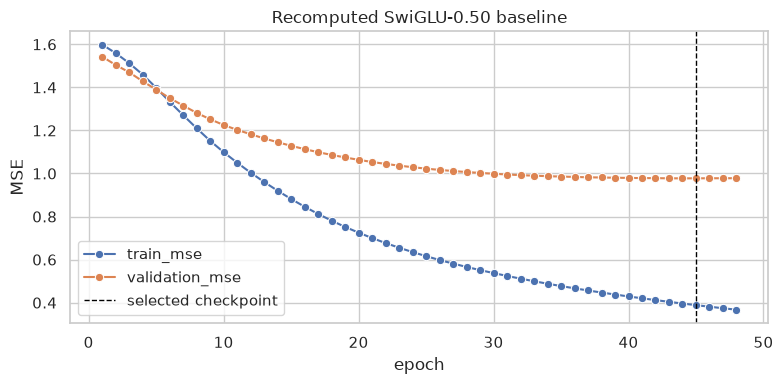

In [11]:
baseline_history_long = baseline_history_df.melt(
    id_vars=['epoch', 'optimizer_updates'],
    value_vars=['train_mse', 'validation_mse'],
    var_name='split',
    value_name='mse',
)

plt.figure(figsize=(8, 4))
sns.lineplot(
    data=baseline_history_long,
    x='epoch',
    y='mse',
    hue='split',
    marker='o',
)
plt.axvline(
    int(baseline_metrics_df.iloc[0]['best_epoch']),
    color='black',
    linestyle='--',
    linewidth=1,
    label='selected checkpoint',
)
plt.title('Recomputed SwiGLU-0.50 baseline')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

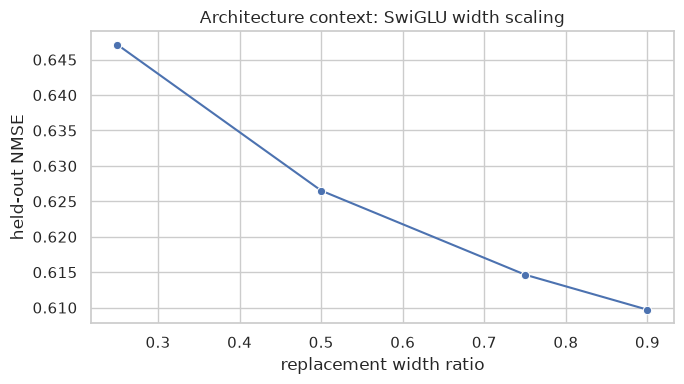

In [12]:
baseline_experiments_artifact = (
    json.loads(
        BASELINE_EXPERIMENTS_ARTIFACT_PATH.read_text(encoding='utf-8')
    )
    if RUN_FROM_SCRATCH
    else None
)
width_scaling_df = pd.DataFrame(
    baseline_experiments_artifact['results']['swiglu_width_scaling']
    if RUN_FROM_SCRATCH
    else loaded_artifact['results']['original_distillation'][
        'width_scaling'
    ]
).sort_values('width_ratio')

plt.figure(figsize=(7, 4))
sns.lineplot(
    data=width_scaling_df,
    x='width_ratio',
    y='local_relative_mse',
    marker='o',
)
plt.title('Architecture context: SwiGLU width scaling')
plt.xlabel('replacement width ratio')
plt.ylabel('held-out NMSE')
plt.tight_layout()
plt.show()

### Fitting improvements

#### Calibration data increase

Compare calibration sizes with the same batch size and a maximum of 64 epochs. This isolates the effect of adding unique activation pairs; larger datasets are intentionally allowed more optimizer updates. Saved outputs below remain from the legacy run until these cells are executed again.

In [13]:
if RUN_FROM_SCRATCH:
    calibration_rows = [baseline_calibration_row]
    calibration_history_rows = [
        {'calibration_tokens': calibration_tokens, **row}
        for row in baseline_history_df.to_dict(orient='records')
    ]
else:
    calibration_rows = []
    calibration_history_rows = []

In [14]:
tokens_per_capture_batch = (
    data_config.batch_size * data_config.sequence_length
)
for num_batches in (
    [
        value for value in CALIBRATION_BATCH_BUDGETS
        if value != data_config.num_calibration_batches
    ]
    if RUN_FROM_SCRATCH
    else []
):
    num_tokens = num_batches * tokens_per_capture_batch
    training_pairs = ActivationPairs(
        inputs=calibration_training_pool.inputs[:num_tokens],
        targets=calibration_training_pool.targets[:num_tokens],
    )
    steps_per_epoch = ceil(
        num_tokens / baseline_training_config.batch_size
    )
    training_config = replace(
        baseline_training_config,
        epochs=CALIBRATION_MAX_EPOCHS,
    )

    torch.manual_seed(SEED)
    fit = fit_operator(
        GatedMLPReplacement(
            hidden_size, replacement_width, bias=False
        ),
        training_pairs,
        calibration_validation_pairs,
        training_config,
        device,
    )
    train_metrics = evaluate_operator(
        fit.module,
        training_pairs,
        device,
        training_config.batch_size,
    )
    validation_metrics = evaluate_operator(
        fit.module,
        calibration_validation_pairs,
        device,
        training_config.batch_size,
    )

    calibration_rows.append({
        'calibration_batches': num_batches,
        'calibration_tokens': num_tokens,
        'operator_batch_size': training_config.batch_size,
        'maximum_epochs': training_config.epochs,
        'completed_epochs': len(fit.history),
        'steps_per_epoch': steps_per_epoch,
        'completed_optimizer_updates': (
            len(fit.history) * steps_per_epoch
        ),
        'best_epoch': fit.best_epoch,
        'best_optimizer_update': (
            fit.best_epoch * steps_per_epoch
        ),
        'pair_presentations': (
            len(fit.history) * num_tokens
        ),
        'selected_train_mse': train_metrics.mse,
        'selected_validation_mse': validation_metrics.mse,
        'train_validation_gap': (
            validation_metrics.mse - train_metrics.mse
        ),
        'heldout_nmse': validation_metrics.relative_mse,
        'heldout_cosine': (
            validation_metrics.cosine_similarity
        ),
    })
    for epoch in fit.history:
        calibration_history_rows.append({
            'calibration_tokens': num_tokens,
            'epoch': epoch.epoch,
            'optimizer_updates': epoch.epoch * steps_per_epoch,
            'pair_presentations': epoch.epoch * num_tokens,
            'train_mse': epoch.train_mse,
            'validation_mse': epoch.validation_mse,
        })

if RUN_FROM_SCRATCH:
    calibration_study_df = pd.DataFrame(calibration_rows)
    calibration_history_df = pd.DataFrame(
        calibration_history_rows
    )
else:
    calibration_results = loaded_artifact['results'][
        'calibration_data'
    ]
    calibration_study_df = pd.DataFrame(
        calibration_results['summary']
    )
    calibration_history_df = pd.DataFrame(
        calibration_results['training_history']
    )

In [15]:
display(calibration_study_df)

,calibration_batches,calibration_tokens,operator_batch_size,maximum_epochs,completed_epochs,steps_per_epoch,completed_optimizer_updates,best_epoch,best_optimizer_update,pair_presentations,selected_train_mse,selected_validation_mse,train_validation_gap,heldout_nmse,heldout_cosine
0,48,12288,2048,64,48,6,288,45,270,589824,0.380676,0.977388,0.596712,0.626515,0.616383
1,96,24576,2048,64,35,12,420,32,384,860160,0.464476,0.882430,0.417954,0.565646,0.665191
2,192,49152,2048,64,28,24,672,25,600,1376256,0.502097,0.802762,0.300665,0.514578,0.702147
3,384,98304,2048,64,29,48,1392,26,1248,2850816,0.486986,0.727923,0.240937,0.466605,0.734943


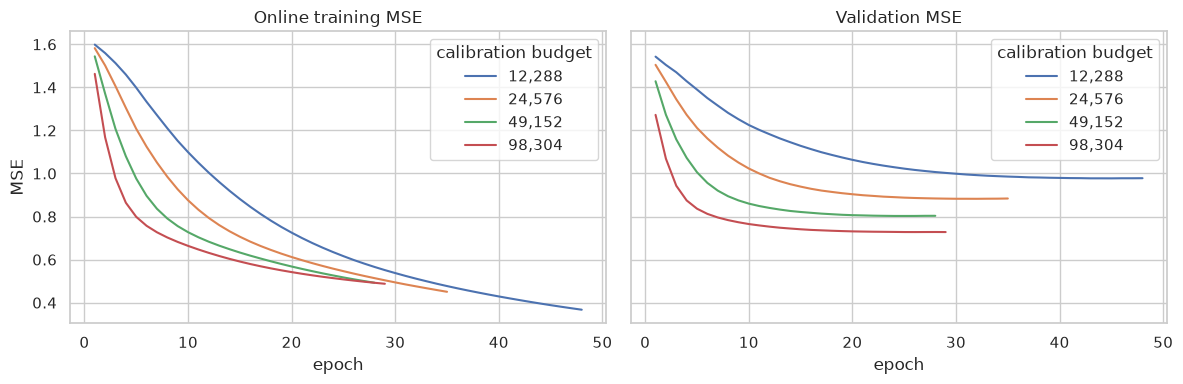

In [16]:
calibration_history_plot_df = calibration_history_df.copy()
calibration_history_plot_df['calibration budget'] = (
    calibration_history_plot_df['calibration_tokens']
    .map(lambda value: f'{value:,}')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.lineplot(
    data=calibration_history_plot_df,
    x='epoch',
    y='train_mse',
    hue='calibration budget',
    ax=axes[0],
)
sns.lineplot(
    data=calibration_history_plot_df,
    x='epoch',
    y='validation_mse',
    hue='calibration budget',
    ax=axes[1],
)
axes[0].set(title='Online training MSE', ylabel='MSE')
axes[1].set(title='Validation MSE', ylabel='MSE')
plt.tight_layout()
plt.show()

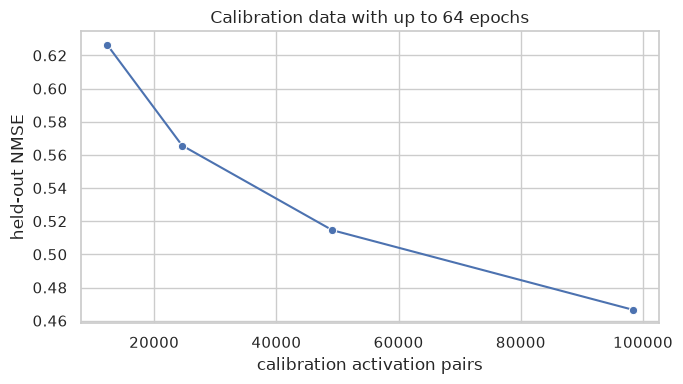

In [17]:
plt.figure(figsize=(7, 4))
sns.lineplot(
    data=calibration_study_df,
    x='calibration_tokens',
    y='heldout_nmse',
    marker='o',
)
plt.title('Calibration data with up to 64 epochs')
plt.xlabel('calibration activation pairs')
plt.ylabel('held-out NMSE')
plt.tight_layout()
plt.show()

#### Training optimization

Screen operator batch sizes 256, 512, 1,024, and 2,048 on the largest calibration pool for 8 fixed epochs. All other fitting settings remain unchanged.

In [18]:
OPERATOR_BATCH_SIZES = [256, 512, 1024, 2048]
TRAINING_OPTIMIZATION_EPOCHS = 8
TRAINING_OPTIMIZATION_SPECS = [
    {
        'configuration': f'batch_{batch_size}',
        'operator_batch_size': batch_size,
    }
    for batch_size in OPERATOR_BATCH_SIZES
]
if not RUN_FROM_SCRATCH:
    OPERATOR_BATCH_SIZES = loaded_artifact[
        'configuration'
    ]['operator_batch_sizes']
    TRAINING_OPTIMIZATION_EPOCHS = loaded_artifact[
        'configuration'
    ]['training_optimization_epochs']
    TRAINING_OPTIMIZATION_SPECS = loaded_artifact[
        'configuration'
    ]['training_optimization_specs']

In [19]:
optimization_calibration_tokens = (
    max(CALIBRATION_BATCH_BUDGETS) * tokens_per_capture_batch
)
optimization_training_pairs = (
    ActivationPairs(
        inputs=calibration_training_pool.inputs[
            :optimization_calibration_tokens
        ],
        targets=calibration_training_pool.targets[
            :optimization_calibration_tokens
        ],
    )
    if RUN_FROM_SCRATCH
    else None
)
optimization_rows = []
optimization_history_rows = []

for spec in (
    TRAINING_OPTIMIZATION_SPECS if RUN_FROM_SCRATCH else []
):
    steps_per_epoch = ceil(
        optimization_calibration_tokens
        / spec['operator_batch_size']
    )
    training_config = replace(
        baseline_training_config,
        epochs=TRAINING_OPTIMIZATION_EPOCHS,
        batch_size=spec['operator_batch_size'],
        early_stopping_patience=None,
    )

    torch.manual_seed(SEED)
    fit = fit_operator(
        GatedMLPReplacement(
            hidden_size, replacement_width, bias=False
        ),
        optimization_training_pairs,
        calibration_validation_pairs,
        training_config,
        device,
    )
    train_metrics = evaluate_operator(
        fit.module,
        optimization_training_pairs,
        device,
        training_config.batch_size,
    )
    validation_metrics = evaluate_operator(
        fit.module,
        calibration_validation_pairs,
        device,
        training_config.batch_size,
    )

    optimization_rows.append({
        **spec,
        'calibration_tokens': optimization_calibration_tokens,
        'maximum_epochs': training_config.epochs,
        'completed_epochs': len(fit.history),
        'steps_per_epoch': steps_per_epoch,
        'completed_optimizer_updates': (
            len(fit.history) * steps_per_epoch
        ),
        'best_epoch': fit.best_epoch,
        'best_optimizer_update': (
            fit.best_epoch * steps_per_epoch
        ),
        'pair_presentations': (
            len(fit.history) * optimization_calibration_tokens
        ),
        'selected_train_mse': train_metrics.mse,
        'selected_validation_mse': validation_metrics.mse,
        'train_validation_gap': (
            validation_metrics.mse - train_metrics.mse
        ),
        'heldout_nmse': validation_metrics.relative_mse,
        'heldout_cosine': (
            validation_metrics.cosine_similarity
        ),
    })
    for epoch in fit.history:
        optimization_history_rows.append({
            'configuration': spec['configuration'],
            'epoch': epoch.epoch,
            'optimizer_updates': (
                epoch.epoch * steps_per_epoch
            ),
            'operator_batch_size': training_config.batch_size,
            'pair_presentations': (
                epoch.epoch * optimization_calibration_tokens
            ),
            'learning_rate': epoch.learning_rate,
            'train_mse': epoch.train_mse,
            'validation_mse': epoch.validation_mse,
        })

if RUN_FROM_SCRATCH:
    training_optimization_df = pd.DataFrame(optimization_rows)
    training_optimization_history_df = pd.DataFrame(
        optimization_history_rows
    )
    best_training_configuration = (
        training_optimization_df
        .sort_values('heldout_nmse')
        .iloc[0]['configuration']
    )
    best_training_spec = next(
        spec.copy() for spec in TRAINING_OPTIMIZATION_SPECS
        if spec['configuration'] == best_training_configuration
    )
else:
    optimization_results = loaded_artifact['results'][
        'training_optimization'
    ]
    training_optimization_df = pd.DataFrame(
        optimization_results['summary']
    )
    training_optimization_history_df = pd.DataFrame(
        optimization_results['training_history']
    )
    best_training_configuration = optimization_results[
        'best_configuration'
    ]
    best_training_spec = optimization_results['best_spec']

In [20]:
training_optimization_report_df = (
    training_optimization_df
    .sort_values('heldout_nmse')
    .reset_index(drop=True)
)
display(training_optimization_report_df)
print(
    'Selected operator batch size: '
    f"{best_training_spec['operator_batch_size']:,}"
)

,configuration,operator_batch_size,calibration_tokens,maximum_epochs,completed_epochs,steps_per_epoch,completed_optimizer_updates,best_epoch,best_optimizer_update,pair_presentations,selected_train_mse,selected_validation_mse,train_validation_gap,heldout_nmse,heldout_cosine
0,batch_256,256,98304,8,8,384,3072,7,2688,786432,0.505723,0.728272,0.222548,0.466829,0.733462
1,batch_512,512,98304,8,8,192,1536,8,1536,786432,0.530284,0.730453,0.200169,0.468227,0.732090
2,batch_1024,1024,98304,8,8,96,768,8,768,786432,0.596994,0.747396,0.150402,0.479088,0.724049
3,batch_2048,2048,98304,8,8,48,384,8,384,786432,0.680526,0.783390,0.102864,0.502160,0.707215


Selected operator batch size: 256


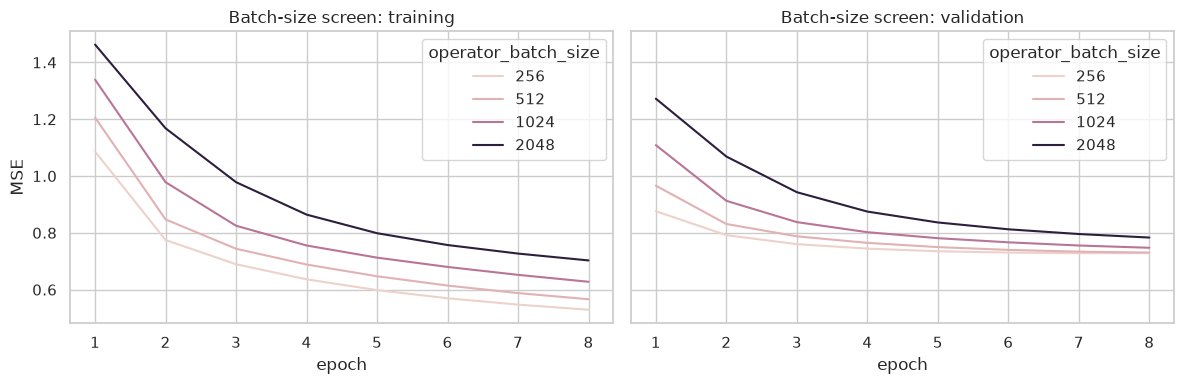

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.lineplot(
    data=training_optimization_history_df,
    x='epoch',
    y='train_mse',
    hue='operator_batch_size',
    ax=axes[0],
)
sns.lineplot(
    data=training_optimization_history_df,
    x='epoch',
    y='validation_mse',
    hue='operator_batch_size',
    ax=axes[1],
)
axes[0].set(title='Batch-size screen: training', ylabel='MSE')
axes[1].set(title='Batch-size screen: validation', ylabel='MSE')
plt.tight_layout()
plt.show()

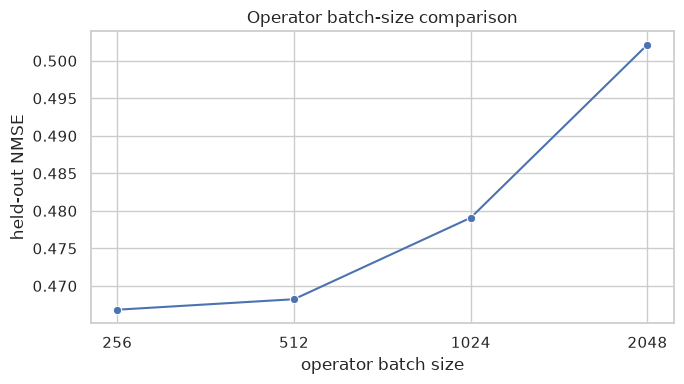

In [22]:
plt.figure(figsize=(7, 4))
sns.lineplot(
    data=training_optimization_report_df,
    x='operator_batch_size',
    y='heldout_nmse',
    marker='o',
)
plt.xscale('log', base=2)
plt.xticks(OPERATOR_BATCH_SIZES, OPERATOR_BATCH_SIZES)
plt.title('Operator batch-size comparison')
plt.xlabel('operator batch size')
plt.ylabel('held-out NMSE')
plt.tight_layout()
plt.show()

#### Calibration data + training optimization

Repeat the 64-epoch calibration-size study with the batch size selected by the short screen, then compare it directly with the batch-2,048 study.

In [23]:
combined_rows = []
combined_history_rows = []

for num_batches in (
    CALIBRATION_BATCH_BUDGETS if RUN_FROM_SCRATCH else []
):
    num_tokens = num_batches * tokens_per_capture_batch
    training_pairs = ActivationPairs(
        inputs=calibration_training_pool.inputs[:num_tokens],
        targets=calibration_training_pool.targets[:num_tokens],
    )
    steps_per_epoch = ceil(
        num_tokens / best_training_spec['operator_batch_size']
    )
    training_config = replace(
        baseline_training_config,
        epochs=CALIBRATION_MAX_EPOCHS,
        batch_size=best_training_spec['operator_batch_size'],
    )

    torch.manual_seed(SEED)
    fit = fit_operator(
        GatedMLPReplacement(
            hidden_size, replacement_width, bias=False
        ),
        training_pairs,
        calibration_validation_pairs,
        training_config,
        device,
    )
    train_metrics = evaluate_operator(
        fit.module,
        training_pairs,
        device,
        training_config.batch_size,
    )
    validation_metrics = evaluate_operator(
        fit.module,
        calibration_validation_pairs,
        device,
        training_config.batch_size,
    )

    combined_rows.append({
        'calibration_batches': num_batches,
        'calibration_tokens': num_tokens,
        'configuration': best_training_configuration,
        'operator_batch_size': training_config.batch_size,
        'maximum_epochs': training_config.epochs,
        'completed_epochs': len(fit.history),
        'steps_per_epoch': steps_per_epoch,
        'completed_optimizer_updates': (
            len(fit.history) * steps_per_epoch
        ),
        'best_epoch': fit.best_epoch,
        'best_optimizer_update': (
            fit.best_epoch * steps_per_epoch
        ),
        'pair_presentations': (
            len(fit.history) * num_tokens
        ),
        'selected_train_mse': train_metrics.mse,
        'selected_validation_mse': validation_metrics.mse,
        'train_validation_gap': (
            validation_metrics.mse - train_metrics.mse
        ),
        'heldout_nmse': validation_metrics.relative_mse,
        'heldout_cosine': (
            validation_metrics.cosine_similarity
        ),
    })
    for epoch in fit.history:
        combined_history_rows.append({
            'calibration_tokens': num_tokens,
            'epoch': epoch.epoch,
            'optimizer_updates': epoch.epoch * steps_per_epoch,
            'pair_presentations': epoch.epoch * num_tokens,
            'train_mse': epoch.train_mse,
            'validation_mse': epoch.validation_mse,
        })

if RUN_FROM_SCRATCH:
    combined_training_df = pd.DataFrame(combined_rows)
    combined_training_history_df = pd.DataFrame(
        combined_history_rows
    )
    combined_comparison_df = (
        calibration_study_df[
            [
                'calibration_tokens',
                'operator_batch_size',
                'completed_optimizer_updates',
                'heldout_nmse',
            ]
        ]
        .rename(columns={
            'operator_batch_size': 'baseline_batch_size',
            'completed_optimizer_updates': (
                'baseline_optimizer_updates'
            ),
            'heldout_nmse': 'original_nmse',
        })
        .merge(
            combined_training_df[
                [
                    'calibration_tokens',
                    'operator_batch_size',
                    'completed_optimizer_updates',
                    'heldout_nmse',
                    'heldout_cosine',
                    'train_validation_gap',
                ]
            ].rename(columns={
                'operator_batch_size': 'optimized_batch_size',
                'completed_optimizer_updates': (
                    'optimized_optimizer_updates'
                ),
                'heldout_nmse': 'optimized_nmse',
            }),
            on='calibration_tokens',
        )
    )
    combined_comparison_df['nmse_reduction'] = (
        combined_comparison_df['original_nmse']
        - combined_comparison_df['optimized_nmse']
    )
else:
    combined_results = loaded_artifact['results']['combined']
    combined_training_df = pd.DataFrame(
        combined_results['summary']
    )
    combined_training_history_df = pd.DataFrame(
        combined_results['training_history']
    )
    combined_comparison_df = pd.DataFrame(
        combined_results['comparison']
    )

In [24]:
display(combined_comparison_df)

,calibration_tokens,baseline_batch_size,baseline_optimizer_updates,original_nmse,optimized_batch_size,optimized_optimizer_updates,optimized_nmse,heldout_cosine,train_validation_gap,nmse_reduction
0,12288,2048,288,0.626515,256,672,0.621963,0.617877,0.591222,0.004552
1,24576,2048,420,0.565646,256,1152,0.561647,0.666503,0.437822,0.003999
2,49152,2048,672,0.514578,256,1920,0.513704,0.701360,0.305444,0.000874
3,98304,2048,1392,0.466605,256,3840,0.466829,0.733462,0.222548,-0.000224


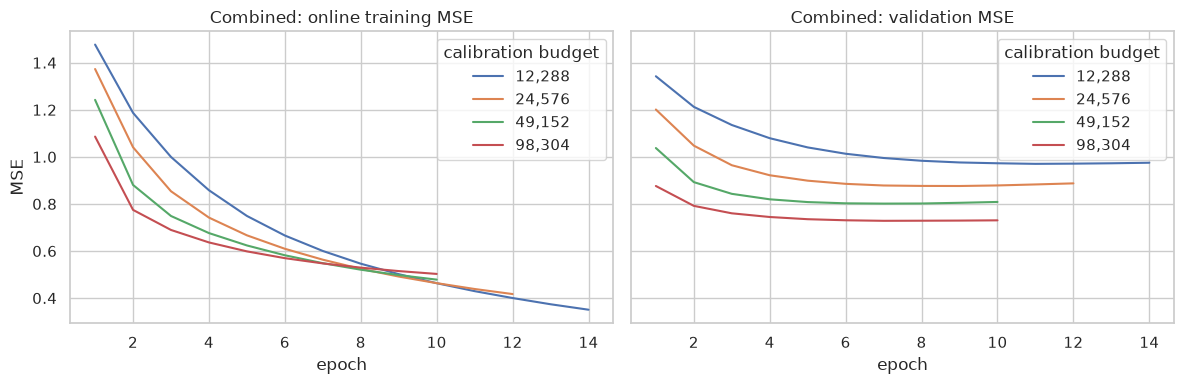

In [25]:
combined_history_plot_df = combined_training_history_df.copy()
combined_history_plot_df['calibration budget'] = (
    combined_history_plot_df['calibration_tokens']
    .map(lambda value: f'{value:,}')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.lineplot(
    data=combined_history_plot_df,
    x='epoch',
    y='train_mse',
    hue='calibration budget',
    ax=axes[0],
)
sns.lineplot(
    data=combined_history_plot_df,
    x='epoch',
    y='validation_mse',
    hue='calibration budget',
    ax=axes[1],
)
axes[0].set(title='Combined: online training MSE', ylabel='MSE')
axes[1].set(title='Combined: validation MSE', ylabel='MSE')
plt.tight_layout()
plt.show()

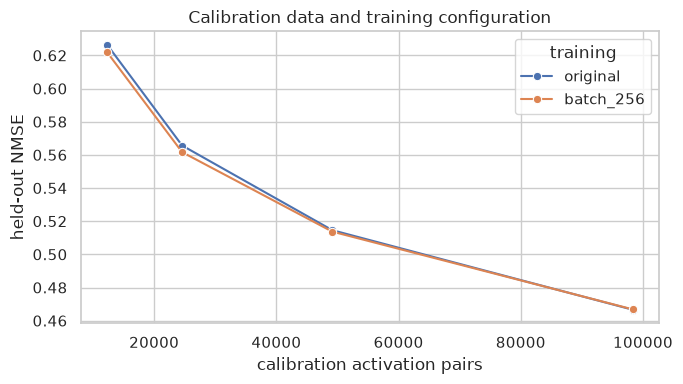

In [26]:
combined_plot_df = combined_comparison_df.melt(
    id_vars='calibration_tokens',
    value_vars=['original_nmse', 'optimized_nmse'],
    var_name='training',
    value_name='heldout_nmse',
)
combined_plot_df['training'] = combined_plot_df['training'].map({
    'original_nmse': 'original',
    'optimized_nmse': best_training_configuration,
})

plt.figure(figsize=(7, 4))
sns.lineplot(
    data=combined_plot_df,
    x='calibration_tokens',
    y='heldout_nmse',
    hue='training',
    marker='o',
)
plt.title('Calibration data and training configuration')
plt.xlabel('calibration activation pairs')
plt.ylabel('held-out NMSE')
plt.tight_layout()
plt.show()

#### Teacher-derived initialization

The purpose of this section is to implement teacher-derived starting weight initialization. Instead of starting from scratch we can re-use some weights from the teacher itself for better local learning.

1) Random init - pick weights randomly from original
2) Informed init - using some sort of weight importance metric pick weights

configuration

In [27]:
TEACHER_INITIALIZATION_BATCH_SIZE = 2048
TEACHER_IMPORTANCE_BATCH_SIZE = 2048
TEACHER_SELECTION_SEED = SEED

if RUN_FROM_SCRATCH:
    teacher_initialization_pairs = optimization_training_pairs
    teacher_initialization_config = replace(
        baseline_training_config,
        epochs=CALIBRATION_MAX_EPOCHS,
        batch_size=TEACHER_INITIALIZATION_BATCH_SIZE,
    )
    teacher_initialization_steps_per_epoch = ceil(
        optimization_calibration_tokens
        / TEACHER_INITIALIZATION_BATCH_SIZE
    )
else:
    saved_teacher_config = loaded_artifact['configuration'][
        'teacher_initialization'
    ]
    TEACHER_INITIALIZATION_BATCH_SIZE = saved_teacher_config[
        'operator_batch_size'
    ]
    TEACHER_IMPORTANCE_BATCH_SIZE = saved_teacher_config[
        'importance_batch_size'
    ]
    TEACHER_SELECTION_SEED = saved_teacher_config['selection_seed']
    teacher_initialization_pairs = None

In [28]:
def fit_teacher_initialized_student(initialization, student):
    student = student.to(device)
    initial_metrics = evaluate_operator(
        student,
        calibration_validation_pairs,
        device,
        TEACHER_INITIALIZATION_BATCH_SIZE,
    )
    fit = fit_operator(
        student,
        teacher_initialization_pairs,
        calibration_validation_pairs,
        teacher_initialization_config,
        device,
    )
    train_metrics = evaluate_operator(
        fit.module,
        teacher_initialization_pairs,
        device,
        TEACHER_INITIALIZATION_BATCH_SIZE,
    )
    validation_metrics = evaluate_operator(
        fit.module,
        calibration_validation_pairs,
        device,
        TEACHER_INITIALIZATION_BATCH_SIZE,
    )
    row = {
        'initialization': initialization,
        'selection_seed': TEACHER_SELECTION_SEED,
        'parameters': sum(
            parameter.numel() for parameter in fit.module.parameters()
        ),
        'initial_nmse': initial_metrics.relative_mse,
        'initial_cosine': initial_metrics.cosine_similarity,
        'completed_epochs': len(fit.history),
        'completed_optimizer_updates': (
            len(fit.history) * teacher_initialization_steps_per_epoch
        ),
        'best_epoch': fit.best_epoch,
        'best_optimizer_update': (
            fit.best_epoch * teacher_initialization_steps_per_epoch
        ),
        'selected_train_mse': train_metrics.mse,
        'selected_validation_mse': validation_metrics.mse,
        'train_validation_gap': (
            validation_metrics.mse - train_metrics.mse
        ),
        'fitted_nmse': validation_metrics.relative_mse,
        'fitted_cosine': validation_metrics.cosine_similarity,
        'nmse_reduction': (
            initial_metrics.relative_mse
            - validation_metrics.relative_mse
        ),
    }
    history = [{
        'initialization': initialization,
        'epoch': 0,
        'optimizer_updates': 0,
        'train_mse': None,
        'validation_mse': initial_metrics.mse,
    }]
    history.extend({
        'initialization': initialization,
        'epoch': epoch.epoch,
        'optimizer_updates': (
            epoch.epoch * teacher_initialization_steps_per_epoch
        ),
        'train_mse': epoch.train_mse,
        'validation_mse': epoch.validation_mse,
    } for epoch in fit.history)
    fit.module.to('cpu')
    return row, history

In [29]:
if RUN_FROM_SCRATCH:
    teacher_initialization_rows = []
    teacher_initialization_history_rows = []

    torch.manual_seed(SEED)
    random_student = GatedMLPReplacement(
        hidden_size, replacement_width, bias=False
    ).to(device)
    random_initial_metrics = evaluate_operator(
        random_student,
        calibration_validation_pairs,
        device,
        TEACHER_INITIALIZATION_BATCH_SIZE,
    )
    random_control = calibration_study_df.loc[
        calibration_study_df['calibration_tokens'].eq(
            optimization_calibration_tokens
        )
    ].iloc[0]
    teacher_initialization_rows.append({
        'initialization': 'random_weights',
        'selection_seed': None,
        'parameters': sum(
            parameter.numel() for parameter in random_student.parameters()
        ),
        'initial_nmse': random_initial_metrics.relative_mse,
        'initial_cosine': random_initial_metrics.cosine_similarity,
        'completed_epochs': int(random_control['completed_epochs']),
        'completed_optimizer_updates': int(
            random_control['completed_optimizer_updates']
        ),
        'best_epoch': int(random_control['best_epoch']),
        'best_optimizer_update': int(
            random_control['best_optimizer_update']
        ),
        'selected_train_mse': random_control['selected_train_mse'],
        'selected_validation_mse': (
            random_control['selected_validation_mse']
        ),
        'train_validation_gap': random_control['train_validation_gap'],
        'fitted_nmse': random_control['heldout_nmse'],
        'fitted_cosine': random_control['heldout_cosine'],
        'nmse_reduction': (
            random_initial_metrics.relative_mse
            - random_control['heldout_nmse']
        ),
    })
    teacher_initialization_history_rows.append({
        'initialization': 'random_weights',
        'epoch': 0,
        'optimizer_updates': 0,
        'train_mse': None,
        'validation_mse': random_initial_metrics.mse,
    })
    for row in calibration_history_df.loc[
        calibration_history_df['calibration_tokens'].eq(
            optimization_calibration_tokens
        )
    ].to_dict(orient='records'):
        teacher_initialization_history_rows.append({
            'initialization': 'random_weights',
            'epoch': row['epoch'],
            'optimizer_updates': row['optimizer_updates'],
            'train_mse': row['train_mse'],
            'validation_mse': row['validation_mse'],
        })
    random_student.to('cpu')
    del random_student

0. full width control check

In [30]:
if RUN_FROM_SCRATCH:
    full_width_indices = torch.arange(original_intermediate_width)
    teacher_dtype = block.module.gate_proj.weight.dtype
    full_width_student = GatedMLPReplacement(
        hidden_size, original_intermediate_width, bias=False
    ).to(device=device, dtype=teacher_dtype)
    initialize_gated_mlp_from_teacher(
        full_width_student, block.module, full_width_indices
    )
    control_pair_count = min(256, validation_tokens)
    control_pairs = ActivationPairs(
        inputs=calibration_validation_pairs.inputs[:control_pair_count],
        targets=calibration_validation_pairs.targets[:control_pair_count],
    )
    control_metrics = evaluate_operator(
        full_width_student,
        control_pairs,
        device,
        control_pair_count,
    )
    full_width_control = {
        'evaluated_pairs': control_pair_count,
        'parameters': sum(
            parameter.numel()
            for parameter in full_width_student.parameters()
        ),
        'mse': control_metrics.mse,
        'nmse': control_metrics.relative_mse,
        'cosine': control_metrics.cosine_similarity,
        'passed': control_metrics.relative_mse <= 1e-5,
    }
    if not full_width_control['passed']:
        raise RuntimeError(
            'The full-width copied SwiGLU does not reproduce the teacher'
        )
    full_width_student.to('cpu')
    del full_width_student

1. Random teacher subset init

In [31]:
if RUN_FROM_SCRATCH:
    selection_generator = torch.Generator().manual_seed(
        TEACHER_SELECTION_SEED
    )
    random_teacher_indices = torch.randperm(
        original_intermediate_width, generator=selection_generator
    )[:replacement_width].sort().values
    random_teacher_student = GatedMLPReplacement(
        hidden_size, replacement_width, bias=False
    )
    initialize_gated_mlp_from_teacher(
        random_teacher_student,
        block.module,
        random_teacher_indices,
    )
    random_teacher_row, random_teacher_history = (
        fit_teacher_initialized_student(
            'random_teacher_subset', random_teacher_student
        )
    )
    teacher_initialization_rows.append(random_teacher_row)
    teacher_initialization_history_rows.extend(
        random_teacher_history
    )
    del random_teacher_student

2. Informed importance teacher init using the metric:

$$
I_i =
\sqrt{\frac{1}{N}\sum_{n=1}^{N} z_i(x_n)^2}
\left\|W_{\mathrm{down}}[:, i]\right\|_2
$$

$$
z_i(x_n) =
\operatorname{SiLU}\left(
    \left(W_{\mathrm{gate}}x_n\right)_i
\right)
\left(W_{\mathrm{up}}x_n\right)_i
$$

we select k-best neurons based on k=round(swiglu_width * d_ff). This is kind of like a hybrid between structured pruning and operator distillation. First equation is inspired by WANDA prior research.

In [32]:
if RUN_FROM_SCRATCH:
    activation_squared_sum = torch.zeros(
        original_intermediate_width, dtype=torch.float64
    )
    activation_count = 0
    teacher_dtype = block.module.gate_proj.weight.dtype
    with torch.no_grad():
        for start in range(
            0,
            optimization_calibration_tokens,
            TEACHER_IMPORTANCE_BATCH_SIZE,
        ):
            teacher_inputs = teacher_initialization_pairs.inputs[
                start:start + TEACHER_IMPORTANCE_BATCH_SIZE
            ].to(device=device, dtype=teacher_dtype)
            intermediate = (
                block.module.act_fn(
                    block.module.gate_proj(teacher_inputs)
                )
                * block.module.up_proj(teacher_inputs)
            )
            activation_squared_sum += (
                intermediate.float().square().sum(dim=0).cpu().double()
            )
            activation_count += intermediate.shape[0]
    del teacher_inputs, intermediate

    rms_activation = (
        activation_squared_sum / activation_count
    ).sqrt()
    down_column_norm = (
        block.module.down_proj.weight.detach()
        .float().norm(dim=0).cpu().double()
    )
    importance_scores = rms_activation * down_column_norm
    importance_score_summary = {
        'minimum': float(importance_scores.min().item()),
        'median': float(importance_scores.median().item()),
        'maximum': float(importance_scores.max().item()),
    }

In [33]:
if RUN_FROM_SCRATCH:
    ranked_indices = torch.argsort(
        importance_scores, descending=True, stable=True
    )
    importance_teacher_indices = (
        ranked_indices[:replacement_width].sort().values
    )
    importance_score_summary['smallest_selected'] = float(
        importance_scores[importance_teacher_indices].min().item()
    )

    importance_teacher_student = GatedMLPReplacement(
        hidden_size, replacement_width, bias=False
    )
    initialize_gated_mlp_from_teacher(
        importance_teacher_student,
        block.module,
        importance_teacher_indices,
    )
    importance_teacher_row, importance_teacher_history = (
        fit_teacher_initialized_student(
            'importance_teacher_subset', importance_teacher_student
        )
    )
    teacher_initialization_rows.append(importance_teacher_row)
    teacher_initialization_history_rows.extend(
        importance_teacher_history
    )
    del importance_teacher_student

In [34]:
if RUN_FROM_SCRATCH:
    teacher_initialization_df = pd.DataFrame(
        teacher_initialization_rows
    )
    teacher_initialization_history_df = pd.DataFrame(
        teacher_initialization_history_rows
    )
else:
    saved_teacher_results = loaded_artifact['results'][
        'teacher_initialization'
    ]
    full_width_control = saved_teacher_results['full_width_control']
    teacher_initialization_df = pd.DataFrame(
        saved_teacher_results['summary']
    )
    teacher_initialization_history_df = pd.DataFrame(
        saved_teacher_results['training_history']
    )
    random_teacher_indices = saved_teacher_results[
        'random_teacher_indices'
    ]
    importance_teacher_indices = saved_teacher_results[
        'importance_teacher_indices'
    ]
    importance_score_summary = saved_teacher_results[
        'importance_score_summary'
    ]

teacher_initialization_report_df = (
    teacher_initialization_df[
        [
            'initialization',
            'initial_nmse',
            'fitted_nmse',
            'nmse_reduction',
            'initial_cosine',
            'fitted_cosine',
            'best_epoch',
            'best_optimizer_update',
            'train_validation_gap',
        ]
    ]
    .sort_values('fitted_nmse')
    .reset_index(drop=True)
)

In [35]:
display(pd.DataFrame([full_width_control]))
display(teacher_initialization_report_df)

,evaluated_pairs,parameters,mse,nmse,cosine,passed
0,256,50331648,0.0,0.0,1.0,True


,initialization,initial_nmse,fitted_nmse,nmse_reduction,initial_cosine,fitted_cosine,best_epoch,best_optimizer_update,train_validation_gap
0,importance_teacher_subset,0.294122,0.203845,0.090277,0.838879,0.892289,4,192,0.074650
1,random_teacher_subset,0.459333,0.265465,0.193868,0.734618,0.859597,7,336,0.115309
2,random_weights,0.999999,0.466605,0.533393,0.001469,0.734943,26,1248,0.240937


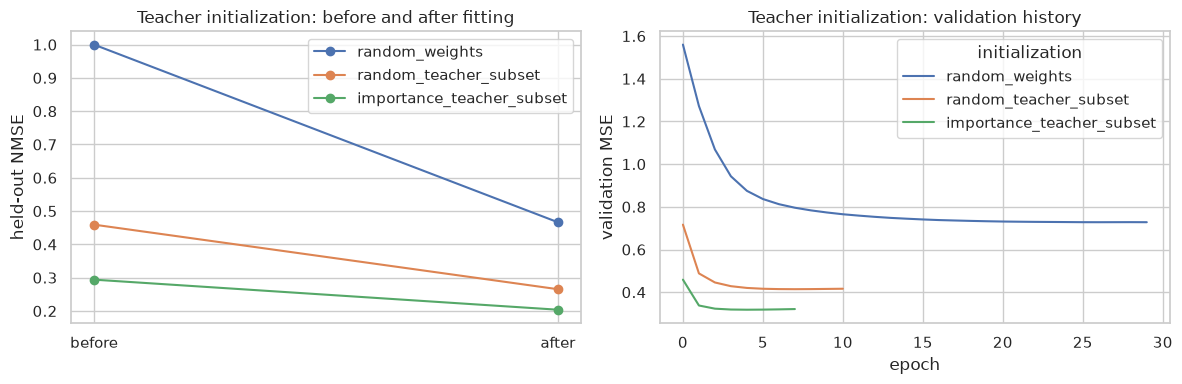

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for row in teacher_initialization_df.to_dict(orient='records'):
    axes[0].plot(
        ['before', 'after'],
        [row['initial_nmse'], row['fitted_nmse']],
        marker='o',
        label=row['initialization'],
    )
sns.lineplot(
    data=teacher_initialization_history_df,
    x='epoch',
    y='validation_mse',
    hue='initialization',
    ax=axes[1],
)
axes[0].set(
    title='Teacher initialization: before and after fitting',
    ylabel='held-out NMSE',
)
axes[1].set(
    title='Teacher initialization: validation history',
    ylabel='validation MSE',
)
axes[0].legend()
plt.tight_layout()
plt.show()

results:

1. calibration data rework improved the performance
2. techer-derived initialization was a gamechanger - improved the NMSE significantly
3. pruning + operator distillation outperformed pure random teacher-derived initialization. Pruning in this context means selecting those neurons for weight initialization who are measured as most important (similiar to prunning).
4. pruning + operator distillation outperformed pure prunning approach. NMSE 0.3 -> 0.2.

#### swiGLU width analysis

In [37]:
SWIGLU_WIDTH_RATIOS = (0.50, 0.60, 0.70, 0.80, 0.90, 0.95)
SWIGLU_WIDTH_INITIALIZATIONS = (
    'random_weights',
    'random_teacher_subset',
    'importance_teacher_subset',
)

if not RUN_FROM_SCRATCH:
    saved_width_config = loaded_artifact['configuration'][
        'swiglu_width_analysis'
    ]
    SWIGLU_WIDTH_RATIOS = tuple(
        saved_width_config['width_ratios']
    )
    SWIGLU_WIDTH_INITIALIZATIONS = tuple(
        saved_width_config['initializations']
    )

In [38]:
if RUN_FROM_SCRATCH:
    swiglu_width_rows = []
    swiglu_width_history_rows = []

    for row in teacher_initialization_df.to_dict(orient='records'):
        width_row = row.copy()
        width_row.update({
            'requested_width_ratio': SWIGLU_WIDTH_RATIOS[0],
            'replacement_width': replacement_width,
            'realized_width_ratio': (
                replacement_width / original_intermediate_width
            ),
            'parameter_retention': (
                row['parameters'] / full_width_control['parameters']
            ),
        })
        swiglu_width_rows.append(width_row)

    for row in teacher_initialization_history_df.to_dict(
        orient='records'
    ):
        swiglu_width_history_rows.append({
            **row,
            'requested_width_ratio': SWIGLU_WIDTH_RATIOS[0],
            'replacement_width': replacement_width,
        })

    width_random_generator = torch.Generator().manual_seed(
        TEACHER_SELECTION_SEED
    )
    width_random_ranking = torch.randperm(
        original_intermediate_width,
        generator=width_random_generator,
    )
    width_importance_ranking = torch.argsort(
        importance_scores, descending=True, stable=True
    )

In [39]:
for width_ratio in (
    SWIGLU_WIDTH_RATIOS[1:] if RUN_FROM_SCRATCH else []
):
    width = max(
        1, round(width_ratio * original_intermediate_width)
    )
    random_subset = width_random_ranking[:width].sort().values
    importance_subset = (
        width_importance_ranking[:width].sort().values
    )
    initialization_specs = (
        ('random_weights', None),
        ('random_teacher_subset', random_subset),
        ('importance_teacher_subset', importance_subset),
    )

    for initialization, neuron_indices in initialization_specs:
        print(
            f'Running width {width_ratio:.0%} | {initialization}'
        )
        torch.manual_seed(SEED)
        student = GatedMLPReplacement(
            hidden_size, width, bias=False
        )
        if neuron_indices is not None:
            initialize_gated_mlp_from_teacher(
                student, block.module, neuron_indices
            )

        row, history = fit_teacher_initialized_student(
            initialization, student
        )
        if initialization == 'random_weights':
            row['selection_seed'] = None
        row.update({
            'requested_width_ratio': width_ratio,
            'replacement_width': width,
            'realized_width_ratio': (
                width / original_intermediate_width
            ),
            'parameter_retention': (
                row['parameters'] / full_width_control['parameters']
            ),
        })
        swiglu_width_rows.append(row)
        swiglu_width_history_rows.extend({
            **epoch,
            'requested_width_ratio': width_ratio,
            'replacement_width': width,
        } for epoch in history)
        del student

Running width 60% | random_weights
Running width 60% | random_teacher_subset
Running width 60% | importance_teacher_subset
Running width 70% | random_weights
Running width 70% | random_teacher_subset
Running width 70% | importance_teacher_subset
Running width 80% | random_weights
Running width 80% | random_teacher_subset
Running width 80% | importance_teacher_subset
Running width 90% | random_weights
Running width 90% | random_teacher_subset
Running width 90% | importance_teacher_subset
Running width 95% | random_weights
Running width 95% | random_teacher_subset
Running width 95% | importance_teacher_subset


In [40]:
if RUN_FROM_SCRATCH:
    swiglu_width_df = pd.DataFrame(swiglu_width_rows)
    swiglu_width_history_df = pd.DataFrame(
        swiglu_width_history_rows
    )
    swiglu_width_reference = {
        'requested_width_ratio': 1.0,
        'replacement_width': original_intermediate_width,
        'realized_width_ratio': 1.0,
        'initialization': 'full_width_teacher_copy',
        'parameters': full_width_control['parameters'],
        'initial_nmse': full_width_control['nmse'],
        'fitted_nmse': full_width_control['nmse'],
        'fitted_cosine': full_width_control['cosine'],
    }

    initial_nmse_by_width = swiglu_width_df.pivot(
        index='requested_width_ratio',
        columns='initialization',
        values='initial_nmse',
    )
    fitted_nmse_by_width = swiglu_width_df.pivot(
        index='requested_width_ratio',
        columns='initialization',
        values='fitted_nmse',
    )
    swiglu_width_comparison_df = pd.DataFrame({
        'requested_width_ratio': fitted_nmse_by_width.index,
        'teacher_copy_advantage': (
            fitted_nmse_by_width['random_weights']
            - fitted_nmse_by_width['random_teacher_subset']
        ).values,
        'importance_selection_advantage': (
            fitted_nmse_by_width['random_teacher_subset']
            - fitted_nmse_by_width['importance_teacher_subset']
        ).values,
    })
    for initialization in SWIGLU_WIDTH_INITIALIZATIONS:
        swiglu_width_comparison_df[
            f'{initialization}_distillation_improvement'
        ] = (
            initial_nmse_by_width[initialization]
            - fitted_nmse_by_width[initialization]
        ).values
else:
    saved_width_results = loaded_artifact['results'][
        'swiglu_width_analysis'
    ]
    swiglu_width_df = pd.DataFrame(
        saved_width_results['summary']
    )
    swiglu_width_history_df = pd.DataFrame(
        saved_width_results['training_history']
    )
    swiglu_width_comparison_df = pd.DataFrame(
        saved_width_results['comparisons']
    )
    swiglu_width_reference = saved_width_results[
        'full_width_reference'
    ]
    width_random_ranking = saved_width_results[
        'random_teacher_ranking'
    ]
    width_importance_ranking = saved_width_results[
        'importance_teacher_ranking'
    ]

swiglu_width_report_df = (
    swiglu_width_df[[
        'requested_width_ratio',
        'realized_width_ratio',
        'replacement_width',
        'initialization',
        'parameters',
        'parameter_retention',
        'initial_nmse',
        'fitted_nmse',
        'nmse_reduction',
        'fitted_cosine',
        'best_epoch',
        'best_optimizer_update',
        'train_validation_gap',
    ]]
    .sort_values(['requested_width_ratio', 'initialization'])
    .reset_index(drop=True)
)

In [41]:
display(swiglu_width_report_df)
display(swiglu_width_comparison_df)

,requested_width_ratio,realized_width_ratio,replacement_width,initialization,parameters,parameter_retention,initial_nmse,fitted_nmse,nmse_reduction,fitted_cosine,best_epoch,best_optimizer_update,train_validation_gap
0,0.50,0.500000,4096,importance_teacher_subset,25165824,0.500000,0.294122,0.203845,0.090277,0.892289,4,192,0.074650
1,0.50,0.500000,4096,random_teacher_subset,25165824,0.500000,0.459333,0.265465,0.193868,0.859597,7,336,0.115309
2,0.50,0.500000,4096,random_weights,25165824,0.500000,0.999999,0.466605,0.533393,0.734943,26,1248,0.240937
3,0.60,0.599976,4915,importance_teacher_subset,30197760,0.599976,0.218863,0.154090,0.064773,0.919732,3,144,0.059071
4,0.60,0.599976,4915,random_teacher_subset,30197760,0.599976,0.367791,0.210100,0.157691,0.890911,6,288,0.100836
5,0.60,0.599976,4915,random_weights,30197760,0.599976,1.000000,0.459371,0.540629,0.739971,24,1152,0.260046
6,0.70,0.699951,5734,importance_teacher_subset,35229696,0.699951,0.152042,0.109414,0.042628,0.943692,2,96,0.040493
7,0.70,0.699951,5734,random_teacher_subset,35229696,0.699951,0.272971,0.156095,0.116875,0.920226,4,192,0.074101
8,0.70,0.699951,5734,random_weights,35229696,0.699951,1.000001,0.453925,0.546076,0.743549,21,1008,0.266914
9,0.80,0.800049,6554,importance_teacher_subset,40267776,0.800049,0.093325,0.068703,0.024622,0.965080,2,96,0.029955


,requested_width_ratio,teacher_copy_advantage,importance_selection_advantage,random_weights_distillation_improvement,random_teacher_subset_distillation_improvement,importance_teacher_subset_distillation_improvement
0,0.50,0.201140,0.061620,0.533393,0.193868,0.090277
1,0.60,0.249271,0.056010,0.540629,0.157691,0.064773
2,0.70,0.297830,0.046681,0.546076,0.116875,0.042628
3,0.80,0.344604,0.034969,0.551724,0.077970,0.024622
4,0.90,0.392020,0.020100,0.556083,0.038466,0.009647
5,0.95,0.415332,0.011355,0.558205,0.019683,0.003770


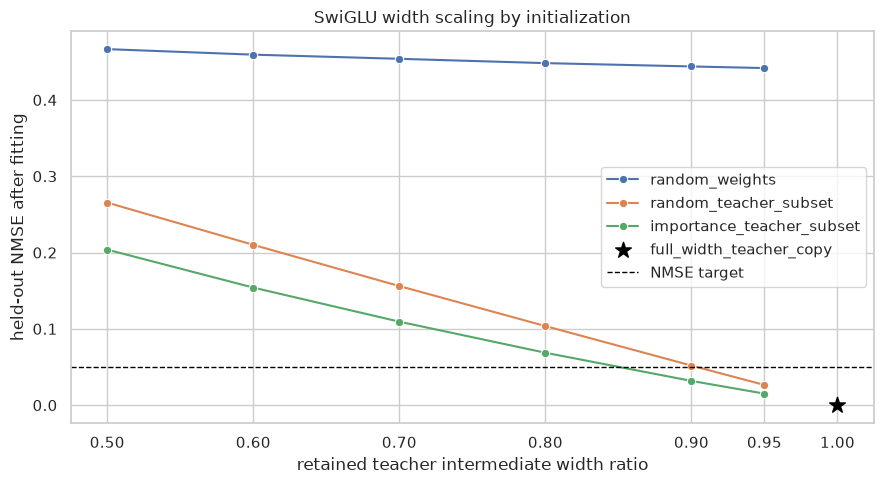

In [42]:
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=swiglu_width_df,
    x='requested_width_ratio',
    y='fitted_nmse',
    hue='initialization',
    marker='o',
)
plt.scatter(
    swiglu_width_reference['requested_width_ratio'],
    swiglu_width_reference['fitted_nmse'],
    marker='*',
    s=140,
    color='black',
    label='full_width_teacher_copy',
)
plt.axhline(
    0.05, color='black', linestyle='--', linewidth=1,
    label='NMSE target',
)
plt.title('SwiGLU width scaling by initialization')
plt.xlabel('retained teacher intermediate width ratio')
plt.ylabel('held-out NMSE after fitting')
plt.xticks((*SWIGLU_WIDTH_RATIOS, 1.0))
plt.legend()
plt.tight_layout()
plt.show()

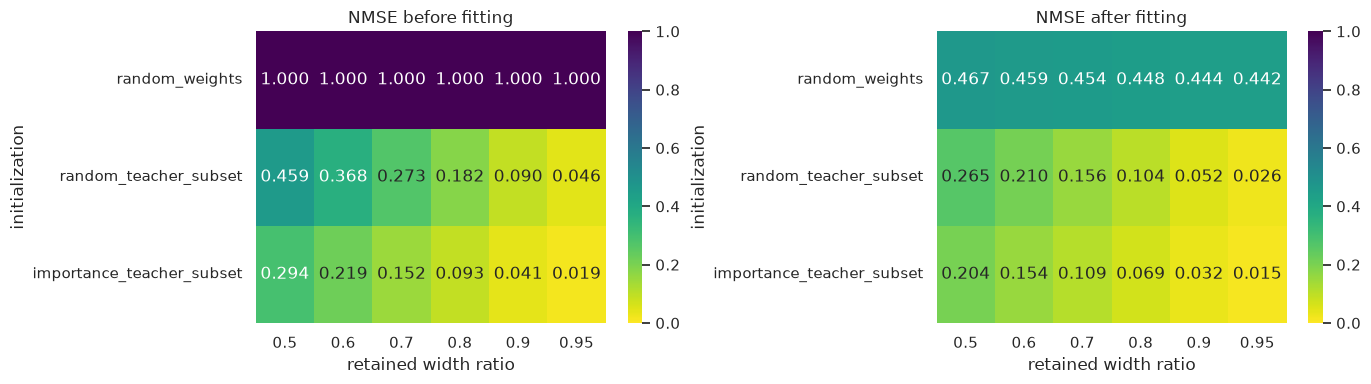

In [43]:
initial_nmse_heatmap = swiglu_width_df.pivot(
    index='initialization',
    columns='requested_width_ratio',
    values='initial_nmse',
).reindex(SWIGLU_WIDTH_INITIALIZATIONS)
fitted_nmse_heatmap = swiglu_width_df.pivot(
    index='initialization',
    columns='requested_width_ratio',
    values='fitted_nmse',
).reindex(SWIGLU_WIDTH_INITIALIZATIONS)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(
    initial_nmse_heatmap,
    annot=True,
    fmt='.3f',
    vmin=0.0,
    vmax=1.0,
    cmap='viridis_r',
    ax=axes[0],
)
sns.heatmap(
    fitted_nmse_heatmap,
    annot=True,
    fmt='.3f',
    vmin=0.0,
    vmax=1.0,
    cmap='viridis_r',
    ax=axes[1],
)
axes[0].set_title('NMSE before fitting')
axes[1].set_title('NMSE after fitting')
for axis in axes:
    axis.set_xlabel('retained width ratio')
    axis.set_ylabel('initialization')
plt.tight_layout()
plt.show()

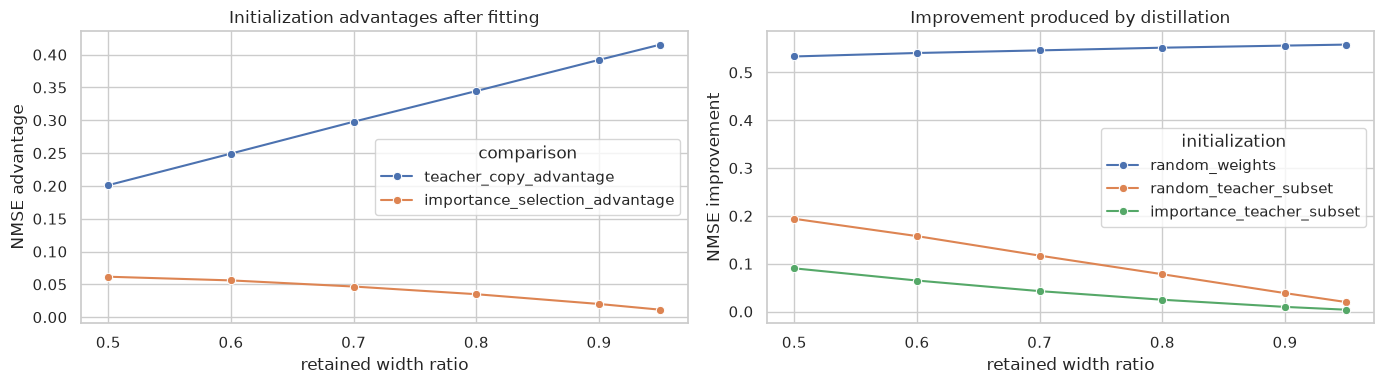

In [44]:
initialization_advantage_plot_df = (
    swiglu_width_comparison_df.melt(
        id_vars='requested_width_ratio',
        value_vars=[
            'teacher_copy_advantage',
            'importance_selection_advantage',
        ],
        var_name='comparison',
        value_name='NMSE advantage',
    )
)
distillation_improvement_plot_df = (
    swiglu_width_comparison_df.melt(
        id_vars='requested_width_ratio',
        value_vars=[
            f'{initialization}_distillation_improvement'
            for initialization in SWIGLU_WIDTH_INITIALIZATIONS
        ],
        var_name='initialization',
        value_name='NMSE improvement',
    )
)
distillation_improvement_plot_df['initialization'] = (
    distillation_improvement_plot_df['initialization'].str.replace(
        '_distillation_improvement', '', regex=False
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(
    data=initialization_advantage_plot_df,
    x='requested_width_ratio',
    y='NMSE advantage',
    hue='comparison',
    marker='o',
    ax=axes[0],
)
sns.lineplot(
    data=distillation_improvement_plot_df,
    x='requested_width_ratio',
    y='NMSE improvement',
    hue='initialization',
    marker='o',
    ax=axes[1],
)
axes[0].set_title('Initialization advantages after fitting')
axes[1].set_title('Improvement produced by distillation')
for axis in axes:
    axis.set_xlabel('retained width ratio')
plt.tight_layout()
plt.show()

___

saving artifact

In [45]:
def json_records(frame):
    return json.loads(
        frame.to_json(orient='records', double_precision=15)
    )


if RUN_FROM_SCRATCH:
    artifact = {
        'schema_version': ARTIFACT_SCHEMA_VERSION,
        'created_at_utc': datetime.now(timezone.utc).isoformat(),
        'configuration': {
            'model': {
                **asdict(model_config),
                'resolved_revision': getattr(
                    model.config, '_commit_hash', None
                ),
            },
            'data': asdict(data_config),
            'calibration_partition': {
                'original_calibration_batches': (
                    data_config.num_calibration_batches
                ),
                'operator_validation_batches': (
                    data_config.num_operator_validation_batches
                ),
                'additional_calibration_batches': (
                    additional_calibration_batches
                ),
                'total_calibration_batches': (
                    max(CALIBRATION_BATCH_BUDGETS)
                ),
            },
            'baseline_training': asdict(
                baseline_training_config
            ),
            'seed': SEED,
            'target_layer': TARGET_LAYER,
            'swiglu_width_ratio': SWIGLU_WIDTH_RATIO,
            'hidden_size': hidden_size,
            'original_intermediate_width': (
                original_intermediate_width
            ),
            'replacement_width': replacement_width,
            'original_calibration_tokens': calibration_tokens,
            'calibration_batch_budgets': list(
                CALIBRATION_BATCH_BUDGETS
            ),
            'calibration_max_epochs': CALIBRATION_MAX_EPOCHS,
            'operator_batch_sizes': list(OPERATOR_BATCH_SIZES),
            'training_optimization_epochs': (
                TRAINING_OPTIMIZATION_EPOCHS
            ),
            'training_optimization_specs': (
                TRAINING_OPTIMIZATION_SPECS
            ),
            'teacher_initialization': {
                'calibration_tokens': optimization_calibration_tokens,
                'operator_batch_size': (
                    TEACHER_INITIALIZATION_BATCH_SIZE
                ),
                'importance_batch_size': (
                    TEACHER_IMPORTANCE_BATCH_SIZE
                ),
                'selection_seed': TEACHER_SELECTION_SEED,
                'retained_neurons': replacement_width,
                'importance_metric': (
                    'rms_post_swiglu_activation_times_'
                    'down_column_l2'
                ),
            },
            'swiglu_width_analysis': {
                'width_ratios': list(SWIGLU_WIDTH_RATIOS),
                'initializations': list(
                    SWIGLU_WIDTH_INITIALIZATIONS
                ),
                'calibration_tokens': (
                    optimization_calibration_tokens
                ),
                'operator_batch_size': (
                    TEACHER_INITIALIZATION_BATCH_SIZE
                ),
                'maximum_epochs': CALIBRATION_MAX_EPOCHS,
                'learning_rate': (
                    teacher_initialization_config.learning_rate
                ),
                'selection_seed': TEACHER_SELECTION_SEED,
            },
        },
        'results': {
            'original_distillation': {
                'configuration': json_records(
                    baseline_config_df
                ),
                'metrics': json_records(baseline_metrics_df),
                'training_history': json_records(
                    baseline_history_df
                ),
                'width_scaling': json_records(width_scaling_df),
            },
            'calibration_data': {
                'summary': json_records(calibration_study_df),
                'training_history': json_records(
                    calibration_history_df
                ),
            },
            'training_optimization': {
                'summary': json_records(
                    training_optimization_df
                ),
                'training_history': json_records(
                    training_optimization_history_df
                ),
                'best_configuration': (
                    best_training_configuration
                ),
                'best_spec': best_training_spec,
            },
            'combined': {
                'summary': json_records(combined_training_df),
                'training_history': json_records(
                    combined_training_history_df
                ),
                'comparison': json_records(
                    combined_comparison_df
                ),
            },
            'teacher_initialization': {
                'full_width_control': full_width_control,
                'summary': json_records(
                    teacher_initialization_df
                ),
                'training_history': json_records(
                    teacher_initialization_history_df
                ),
                'random_teacher_indices': (
                    random_teacher_indices.tolist()
                ),
                'importance_teacher_indices': (
                    importance_teacher_indices.tolist()
                ),
                'importance_score_summary': (
                    importance_score_summary
                ),
            },
            'swiglu_width_analysis': {
                'summary': json_records(swiglu_width_df),
                'training_history': json_records(
                    swiglu_width_history_df
                ),
                'comparisons': json_records(
                    swiglu_width_comparison_df
                ),
                'full_width_reference': (
                    swiglu_width_reference
                ),
                'random_teacher_ranking': (
                    width_random_ranking.tolist()
                ),
                'importance_teacher_ranking': (
                    width_importance_ranking.tolist()
                ),
            },
        },
    }
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    OUTPUT_PATH.write_text(
        json.dumps(artifact, indent=2, allow_nan=False),
        encoding='utf-8',
    )
    print(f'Saved operator-distillation artifact to {OUTPUT_PATH}')
else:
    artifact = loaded_artifact
    print(f'Loaded operator-distillation artifact from {OUTPUT_PATH}')

Saved operator-distillation artifact to /home/sgulas/thesis/development/data/results/notebook-block-study/operator-distillation-v4.json


## Findings & Solutions

The following section contains findings in study of operator fitting, documents problems and their respective solutions.

1. Calibration data and training budget

   Problem: The original study limited every data size to 384 optimizer updates. More calibration data therefore meant fewer passes over each pair, so the 0.487 NMSE result was a fixed-compute result rather than a clean data-scaling result.

   Solution: The reworked study gives every calibration size the same maximum of 64 epochs at batch size 2,048, with early stopping. Larger datasets now produce proportionally more optimizer updates.

2. Random student initialization

   Problem: The student starts with random weights and must relearn a large nonlinear operator only from input-output pairs. The planned comparison with teacher-derived initialization is not implemented.

   Solution: First verify that a full-width student initialized from the teacher gives near-zero NMSE. Then initialize reduced-width students by selecting teacher intermediate units and fine-tune them with local distillation.

3. Width is not the main limitation in the current setting

   Problem: Increasing the student width from 25% to 90% improves NMSE only from about 0.647 to 0.610. More capacity does not solve insufficient data or optimization when the student is trained from scratch.

   Solution: Compare random and teacher-derived initialization at the same widths before increasing model size further. Include a full-width random student to separate optimization failure from compression error.

4. The target may be too strict for the selected compression

   Problem: Layer 11 intermediate activations are not strongly low-dimensional. A non-deployable rank-4096 PCA reconstruction still has about 0.232 output NMSE. This is not a lower bound for SwiGLU, but it shows that retaining half the intermediate dimension does not preserve almost all output information automatically. The NMSE target of 0.05 is currently a project goal rather than an empirically justified threshold.

   Solution: Use the PCA result as an oracle reference, not as a direct baseline. Determine realistic local targets together with model-level quality measurements and test whether teacher-derived structured compression can outperform the PCA reference.

5. The original training optimization search was not informative

   Problem: Learning-rate, scheduler, and weight-decay variants produced nearly identical results, while the operator batch size remained fixed at 2,048. That large batch gives relatively few parameter updates per epoch.

   Solution: The reworked optimization section compares batch sizes 256, 512, 1,024, and 2,048 on the largest calibration pool for 8 complete epochs. The selected batch size is then used in the combined 64-epoch calibration study.

6. The historical baseline used the wrong width semantics

   Problem: The copied historical result interpreted a 0.50 ratio against the 2,048-wide model representation, producing a 1,024-wide operator with 6.29 million parameters. A true 0.50 reduction of the teacher d_ff=8,192 requires a 4,096-wide operator with 25.17 million parameters.

   Solution: The notebook now recomputes the corrected baseline directly. It uses the original 48 calibration batches and a fixed 24-batch validation partition before drawing any additional calibration data, so every later comparison reuses the same baseline data and validation set.

7. The train-validation gap is not measured consistently

   Problem: The epoch training MSE is averaged while the model changes, whereas validation MSE is measured using one frozen state. Subtracting those values did not give an exact generalization gap.

   Solution: The summary tables now recompute training and validation MSE from the selected checkpoint. History plots keep the online training MSE and label it accordingly.

8. The validation set is reused for several decisions

   Problem: The same operator-validation set selects the best epoch, calibration budget, and training configuration. It is document-disjoint from training, which is good, but repeated selection makes it unsuitable as an unbiased final local evaluation.

   Solution: Keep this split for model selection and introduce a separate operator-test split that is evaluated only after the fitting recipe is frozen.

9. Local fit is not final model quality

   Problem: NMSE measures isolated MLP imitation and does not directly determine language-model quality because residual connections and later layers can compensate for local errors. The best 0.487 operator is not evaluated inside the complete model in this notebook.

   Solution: Use NMSE, cosine similarity, R2, norm ratio, and token-level errors as local diagnostics. Make final decisions using matched full-model loss, perplexity, downstream quality, and compression measurements.